In [ ]:
# import regressor
import pandas as pd
import numpy as np
import sys
import math

# import tensorflow as tf
# from tensorflow.keras.models import Sequential
# from tensorflow.keras.layers import SimpleRNN, Dense

!{sys.executable} -m pip install xgboost lightgbm tensorflow

from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df_14_1 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_14_1.csv')
df_14_2 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_14_2.csv')
df_21 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_21.csv')
df_24_1 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_24_1.csv')
df_24_2 = pd.read_csv('/content/drive/MyDrive/Belajar (PTA TA)/vehicle_logs_tread_24_2.csv')

In [ ]:
common_features = ['sum_distance_traveled_m', 'distance_traveled_m', 'elevation_traveled_m', 'speed', 'engine_load']

def fixing(df):
    df_fr = df[common_features + ['fr_temp', 'fr_pressure', 'tr_fr']]
    df_fr.rename(columns={'fr_temp': 'temp', 'fr_pressure': 'pressure', 'tr_fr': 'tr'}, inplace=True)
    df_fr['side'] = 0
    df_fl = df[common_features + ['fl_temp', 'fl_pressure', 'tr_fl']]
    df_fl.rename(columns={'fl_temp': 'temp', 'fl_pressure': 'pressure', 'tr_fl': 'tr'}, inplace=True)
    df_fl['side'] = 1
    df_rr = df[common_features + ['rr_temp', 'rr_pressure', 'tr_rr']]
    df_rr.rename(columns={'rr_temp': 'temp', 'rr_pressure': 'pressure', 'tr_rr': 'tr'}, inplace=True)
    df_rr['side'] = 2
    df_rl = df[common_features + ['rl_temp', 'rl_pressure', 'tr_rl']]
    df_rl.rename(columns={'rl_temp': 'temp', 'rl_pressure': 'pressure', 'tr_rl': 'tr'}, inplace=True)
    df_rl['side'] = 3

    return df_fr, df_fl, df_rr, df_rl

df_14_1_fr, df_14_1_fl, df_14_1_rr, df_14_1_rl = fixing(df_14_1)
df_14_2_fl, df_14_2_fr, df_14_2_rr, df_14_2_rl = fixing(df_14_2)
df_21_fl, df_21_fr, df_21_rr, df_21_rl = fixing(df_21)
df_24_1_fl, df_24_1_fr, df_24_1_rr, df_24_1_rl = fixing(df_24_1)
df_24_2_fl, df_24_2_fr, df_24_2_rr, df_24_2_rl = fixing(df_24_2)

/tmp/ipython-input-2948105280.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fr.rename(columns={'fr_temp': 'temp', 'fr_pressure': 'pressure', 'tr_fr': 'tr'}, inplace=True)
/tmp/ipython-input-2948105280.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fr['side'] = 0
/tmp/ipython-input-2948105280.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_fl.rename(columns

In [ ]:
from sklearn.model_selection import train_test_split

# split datasets 70% for training and 30% for testing
def split_data(df):
    train_size = int(len(df) * 0.8)
    train_data = df[:train_size]
    test_data = df[train_size:]
    return train_data, test_data
    # return train_test_split(df, test_size=0.3, random_state=42)

datasets = [df_14_1_fr, df_14_1_fl, df_14_1_rr, df_14_1_rl,
            df_14_2_fr, df_14_2_fl, df_14_2_rr, df_14_2_rl,
            df_21_fr, df_21_fl, df_21_rr, df_21_rl,
            df_24_1_fr, df_24_1_fl, df_24_1_rr, df_24_1_rl,
            df_24_2_fr, df_24_2_fl, df_24_2_rr, df_24_2_rl]

def apply_denoising(df, window=10):
    df_denoised = df.copy()
    df_denoised = \
        df_denoised.rolling(window=window, min_periods=1).mean()
    return df_denoised

def remove_outliers(series):
    series_no_outliers = series.copy()
    Q1 = series_no_outliers.quantile(0.25)
    Q3 = series_no_outliers.quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    series_no_outliers = series_no_outliers[~((series_no_outliers < lower_bound) | (series_no_outliers > upper_bound))]
    return series_no_outliers

def remove_outliers_1(df, col='tr', limit=400, wiggle_range=(-3, 3)):
    df_no_outliers = df.copy()
    # Cap values at the limit and add a random wiggle
    df_no_outliers[col] = df_no_outliers[col].apply(lambda x: limit + np.random.uniform(wiggle_range[0], wiggle_range[1]) if x > limit else x)
    return df_no_outliers


ave = 0
for i in range(len(datasets)):
    # Add lag_tr feature
    datasets[i].loc[:, 'tr'] = datasets[i]['tr'] * 1e+6
    datasets[i].loc[:, 'lag_tr'] = datasets[i]['tr'].shift(1) # Fill NaN with 0
    datasets[i].loc[:, 'lag_tr'] = datasets[i]['lag_tr'].fillna(datasets[i]['tr'])

    # datasets[i].loc[:, 'tr'] = 6.4 / datasets[i]['tr'] / 564000 * 40000
    # datasets[i].loc[:, 'tr'] = remove_outliers(datasets[i]['tr'])
    # datasets[i]['distance_traveled_m'] = remove_outliers(datasets[i]['distance_traveled_m'], col='distance_traveled_m')
    # datasets[i]['speed'] = remove_outliers(datasets[i]['speed'], col='speed')

    ave += datasets[i]['tr'].sum()

ave /= sum([len(dataset) for dataset in datasets])
print(ave)


train = []
test = []

for dataset in datasets:
    train_data, test_data = split_data(dataset)
    train.append(train_data)
    test.append(test_data)

1.3246064848014831


/tmp/ipython-input-1684471658.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datasets[i].loc[:, 'lag_tr'] = datasets[i]['tr'].shift(1) # Fill NaN with 0
/tmp/ipython-input-1684471658.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  datasets[i].loc[:, 'lag_tr'] = datasets[i]['tr'].shift(1) # Fill NaN with 0
/tmp/ipython-input-1684471658.py:46: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the 

In [ ]:
datasets[0].head()

,sum_distance_traveled_m,distance_traveled_m,elevation_traveled_m,speed,engine_load,temp,pressure,tr,side,lag_tr
0,1.548200,1.548200,0.1,3,60.00000,35.0,28.86149,1.526898,0,1.526898
1,4.125716,2.577515,0.3,1,81.56863,35.0,28.86149,1.526898,0,1.526898
2,6.271934,2.146218,0.7,1,62.35294,35.0,28.86149,1.526898,0,1.526898
3,7.287670,1.015736,0.9,1,59.60784,35.0,28.86149,1.526898,0,1.526898
4,9.109016,1.821346,0.4,1,84.70588,35.0,28.86149,1.526898,0,1.526898


In [ ]:
# define 3 models rnn, xgboos, lightgbm and their hyperparam
import xgboost as xgb
import lightgbm as lgb

xgboost_model = xgb.XGBRegressor()
lightgbm_model = lgb.LGBMRegressor()

xgboost_hyperparam = {
    # 1. Boosting Parameters
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],         # Step size shrinkage
    # 'n_estimators': [100, 300, 500, 1000],          # Number of boosting rounds (use with early stopping)
    # 'booster': ['gbtree'],                          # Booster type

    # 2. Tree Complexity Parameters
    'max_depth': [3, 5, 7, 10],                     # Maximum depth of a tree
    'min_child_weight': [1, 5, 10],                 # Minimum sum of instance weight (Hessian) needed in a child
    'gamma': [0.0, 0.1, 0.5, 1.0]                   # Minimum loss reduction required to make a further partition

    # 3. Sampling Parameters
    # 'subsample': [0.6, 0.8, 1.0],                   # Fraction of training instances to be sampled (rows)
    # 'colsample_bytree': [0.6, 0.8, 1.0],            # Fraction of columns to be sampled per tree

    # 4. Regularization Parameters
    # 'reg_alpha': [0, 0.001, 0.01, 0.1],             # L1 regularization term on weights
    # 'reg_lambda': [0, 0.001, 0.01, 0.1, 1.0],       # L2 regularization term on weights

    # 5. General Parameters (often fixed, but good to know)
    # 'objective': ['reg:squarederror'],
    # 'eval_metric': ['rmse']
}

lightgbm_hyperparam = {
    # 1. Boosting Parameters
    # 'learning_rate': [0.01, 0.05, 0.1, 0.2],         # Step size shrinkage
    # 'n_estimators': [100, 300, 500, 1000],          # Number of boosting rounds (use with early stopping)
    # 'boosting_type': ['gbdt'],                      # GBDT or 'dart', 'goss'

    # 2. Tree Complexity Parameters (Primary: num_leaves)
    'num_leaves': [20, 31, 50, 80],                 # Maximum number of leaves in a tree (KEY PARAMETER)
    'min_child_samples': [20, 50, 100],             # Minimum number of data points in a leaf
    'max_depth': [-1, 5, 8],                        # Maximum tree depth (-1 means no limit)

    # 3. Sampling Parameters
    # 'bagging_fraction': [0.6, 0.8, 1.0],            # Fraction of data to be used for each iteration (rows)
    # 'bagging_freq': [1],                            # Perform bagging every 'k' iterations
    # 'feature_fraction': [0.6, 0.8, 1.0],            # Fraction of features to be used for each tree (columns)

    # 4. Regularization Parameters
    # 'lambda_l1': [0, 0.001, 0.01, 0.1],             # L1 regularization term on weights
    # 'lambda_l2': [0, 0.001, 0.01, 0.1, 1.0],        # L2 regularization term on weights

    # 5. General Parameters (often fixed)
    # 'objective': ['regression'],
    # 'metric': ['r2'],

    'force_col_wise': [True]
}

In [ ]:
from sklearn.model_selection import GridSearchCV
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

xgboost_grid = GridSearchCV(estimator=xgboost_model, param_grid=xgboost_hyperparam, cv=3, verbose=2, n_jobs=-1)
lightgbm_grid = GridSearchCV(estimator=lightgbm_model, param_grid=lightgbm_hyperparam, cv=3, verbose=2, n_jobs=-1)

train_con = pd.concat([x for x in train])

train_con_scaled = scaler.fit_transform(train_con.drop(['tr', 'sum_distance_traveled_m'], axis=1))
xgboost_grid.fit(train_con_scaled, train_con['tr'])
lightgbm_grid.fit(train_con_scaled, train_con['tr'])

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Fitting 3 folds for each of 36 candidates, totalling 108 fits
[LightGBM] [Info] Total Bins 755
[LightGBM] [Info] Number of data points in the train set: 9052, number of used features: 8
[LightGBM] [Info] Start training from score 1.413697
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

GridSearchCV(cv=3, estimator=LGBMRegressor(), n_jobs=-1,
             param_grid={'force_col_wise': [True], 'max_depth': [-1, 5, 8],
                         'min_child_samples': [20, 50, 100],
                         'num_leaves': [20, 31, 50, 80]},
             verbose=2)

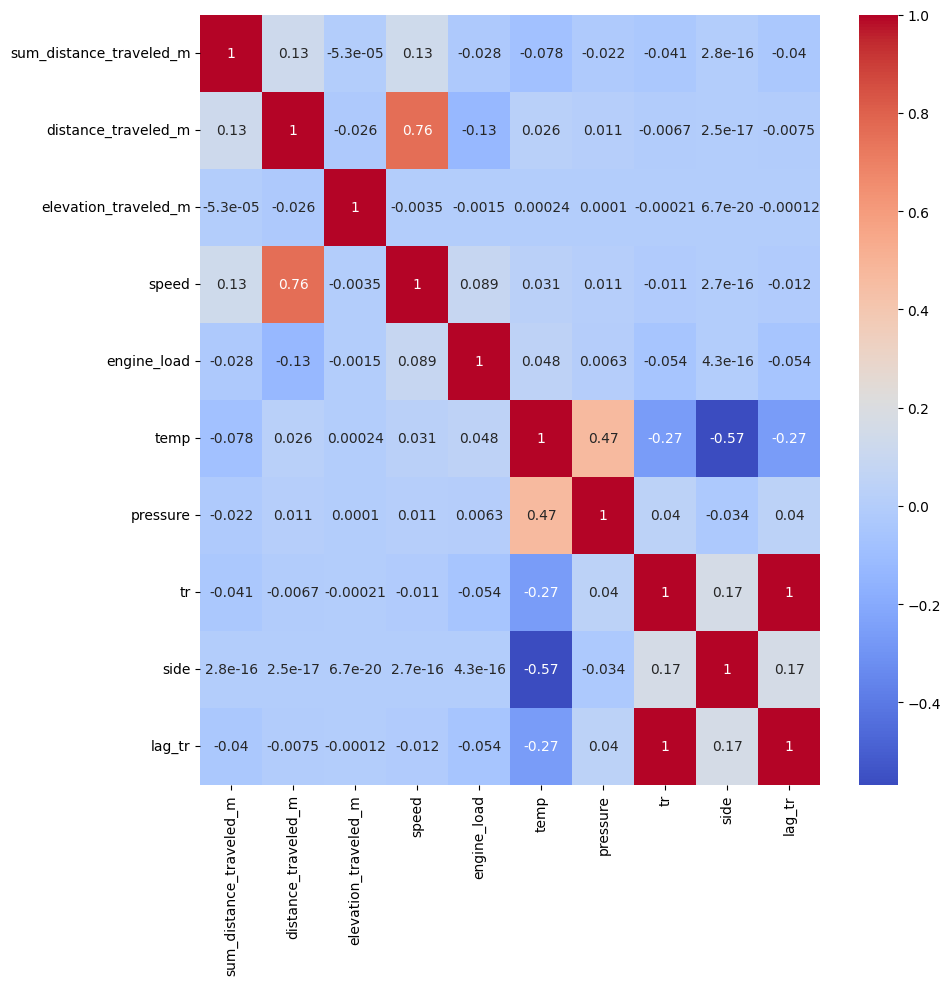

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns

# heatmap
plt.figure(figsize=(10, 10))
sns.heatmap(train_con.corr(), annot=True, cmap='coolwarm')
plt.show()

In [ ]:
xgboost_prediction = []
lightgbm_prediction = []

for i in range(len(test)):
    # predict with hyperparam
    xgboost_best_estimator = xgboost_grid.best_estimator_
    lightgbm_best_estimator = lightgbm_grid.best_estimator_

    test_scaled = scaler.transform(test[i].drop(['tr', 'sum_distance_traveled_m'], axis=1))

    # Generate raw predictions
    raw_xgboost_pred = xgboost_best_estimator.predict(test_scaled)
    raw_lightgbm_pred = lightgbm_best_estimator.predict(test_scaled)

    # Apply denoising to predictions
    # The apply_denoising function expects a Series or DataFrame, so convert and convert back
    # smoothed_xgboost_pred = apply_denoising(pd.Series(raw_xgboost_pred)).values
    # smoothed_lightgbm_pred = apply_denoising(pd.Series(raw_lightgbm_pred)).values

    xgboost_prediction.append(raw_xgboost_pred)
    lightgbm_prediction.append(raw_lightgbm_pred)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/v

In [ ]:
# mape smape mase
import numpy as np
from sklearn.metrics import mean_absolute_percentage_error

def symmetric_mean_absolute_percentage_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    return np.mean(np.abs(y_pred - y_true) / ((np.abs(y_true) + np.abs(y_pred)) / 2))

def mean_absolute_scaled_error(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    # Calculate MAE of the model
    mae = np.mean(np.abs(y_pred - y_true))
    # Calculate MAE of the naive forecast (y_t = y_{t-1})
    # Ensure y_true has at least 2 elements for differencing
    if len(y_true) < 2:
        return np.nan # Or handle error appropriately
    naive_mae = np.mean(np.abs(y_true[1:] - y_true[:-1]))
    # Avoid division by zero
    if naive_mae == 0:
        return np.inf # If naive forecast has zero error, MASE is infinite if mae > 0
    return mae / naive_mae

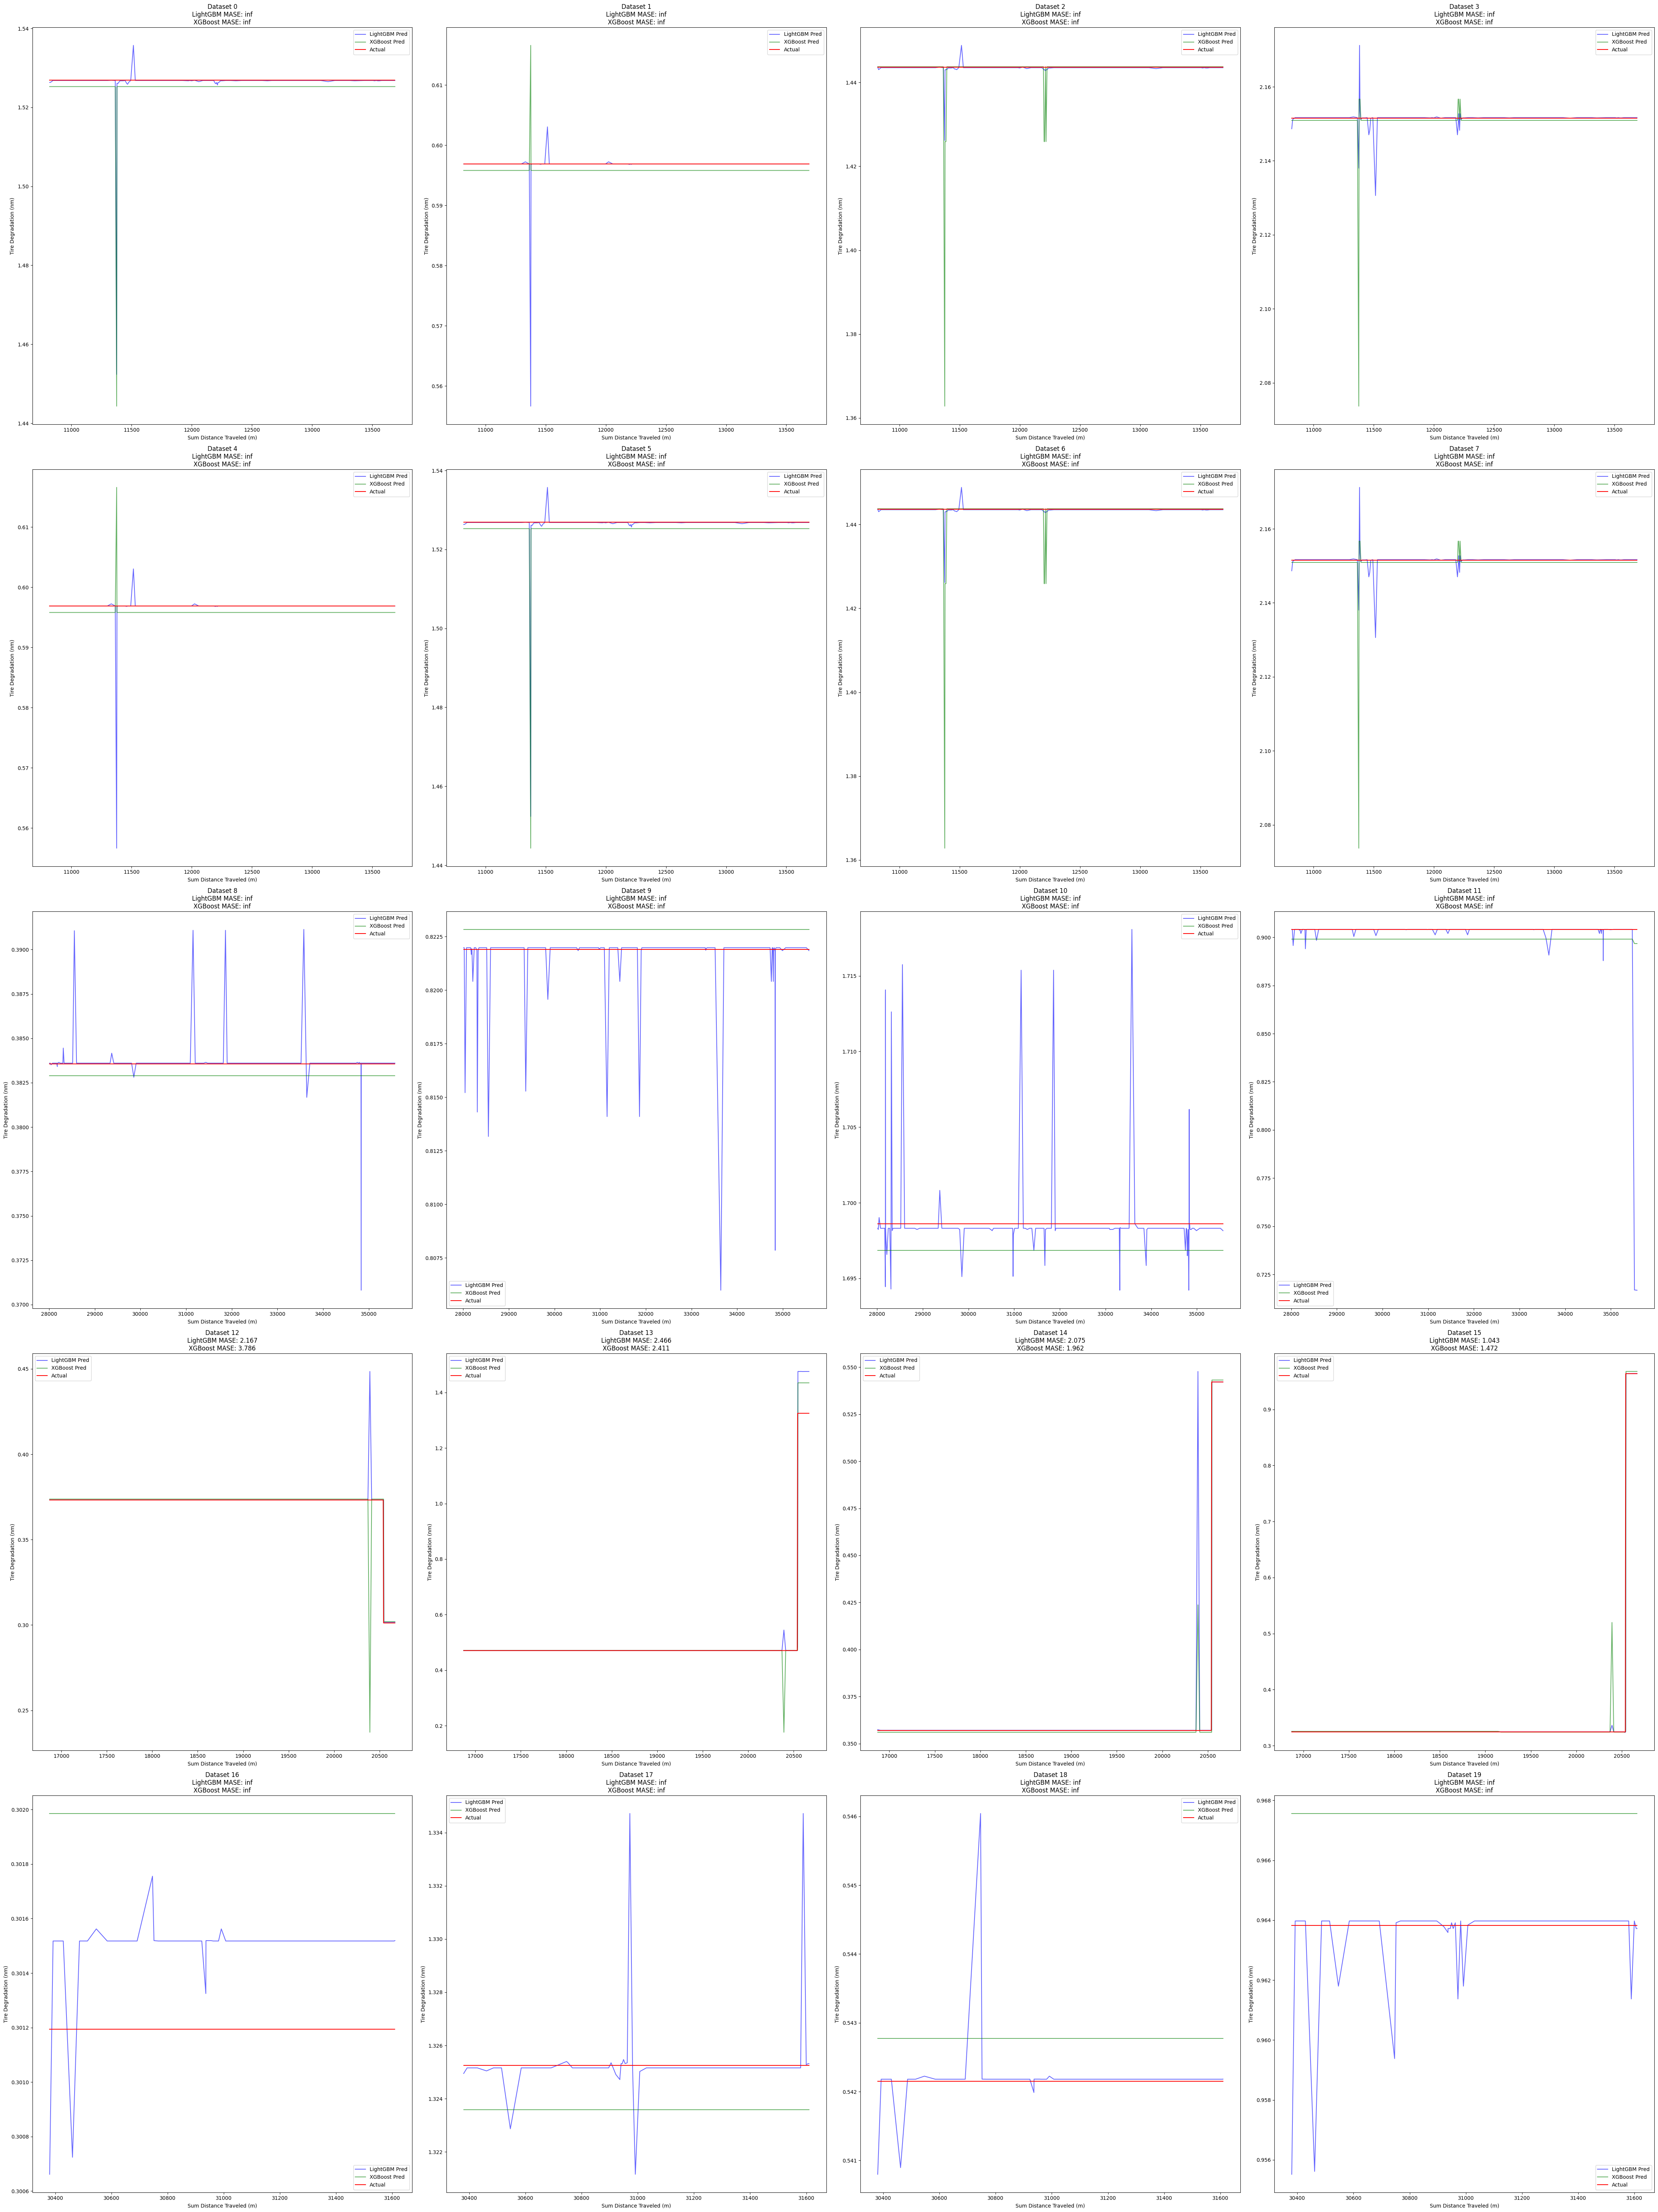

In [ ]:
# compare test and prediction using line graph in time series (m traveled)
import matplotlib.pyplot as plt

# show all graphs side by side in 4x5 fashion
plt.figure(figsize=(45, 60)) # Adjusted figure size for better readability with more lines
for i in range(len(lightgbm_prediction)):
    plt.subplot(5, 4, i + 1)
    plt.plot(test[i]['sum_distance_traveled_m'], lightgbm_prediction[i], label='LightGBM Pred', color='blue', alpha=0.6)
    plt.plot(test[i]['sum_distance_traveled_m'], xgboost_prediction[i], label='XGBoost Pred', color='green', alpha=0.6)
    plt.plot(test[i]['sum_distance_traveled_m'], test[i]['tr'], label='Actual', color='red')
    plt.xlabel('Sum Distance Traveled (m)')
    plt.ylabel('Tire Degradation (nm)')
    plt.title(f'Dataset {i}\nLightGBM MASE: {mean_absolute_scaled_error(test[i]["tr"], lightgbm_prediction[i]):.3f}\nXGBoost MASE: {mean_absolute_scaled_error(test[i]["tr"], xgboost_prediction[i]):.3f}')
    plt.legend()
plt.tight_layout()
plt.show()

Best Dataset: 15


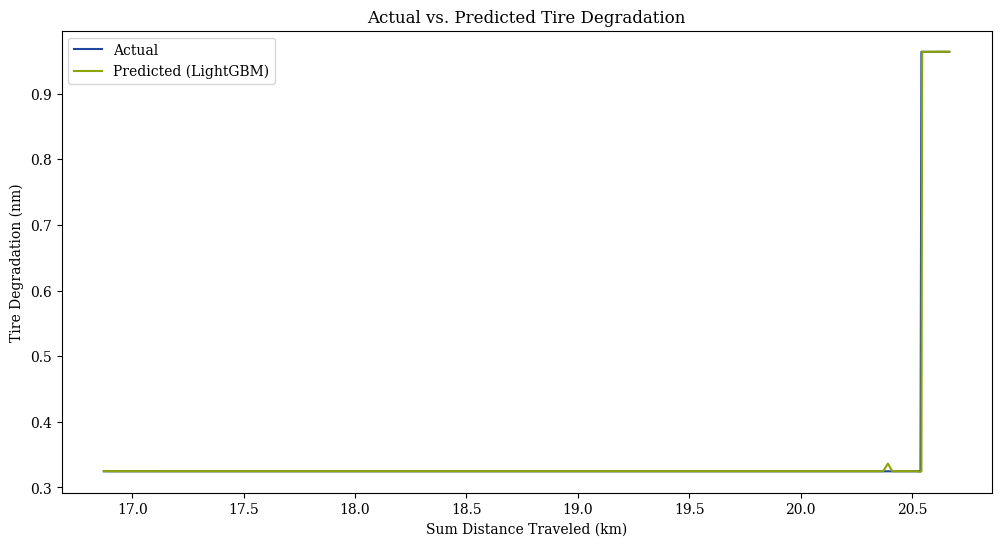

In [ ]:
# showing plot with best result of dataset

# Initialize with a very high MASE value and no best prediction yet
best_mase_value = float('inf')
best_prediction_array = None
best_dataset_index = -1
best_model_name = ''

# Check LightGBM predictions
for i in range(len(lightgbm_prediction)):
    current_actual = test[i]['tr']
    current_prediction = lightgbm_prediction[i]
    current_mase = mean_absolute_scaled_error(current_actual, current_prediction)

    if current_mase < best_mase_value:
        best_mase_value = current_mase
        best_prediction_array = current_prediction
        best_dataset_index = i
        best_model_name = 'LightGBM'

# Check XGBoost predictions
for i in range(len(xgboost_prediction)):
    current_actual = test[i]['tr']
    current_prediction = xgboost_prediction[i]
    current_mase = mean_absolute_scaled_error(current_actual, current_prediction)

    if current_mase < best_mase_value:
        best_mase_value = current_mase
        best_prediction_array = current_prediction
        best_dataset_index = i
        best_model_name = 'XGBoost'

# Plot the best result found
if best_dataset_index != -1:
    print(f"Best Dataset: {best_dataset_index}")
    plt.figure(figsize=(12, 6))

    # Apply requested font style
    plt.rcParams['font.family'] = 'serif'

    # Plot 'Actual' with the specified blue hex code
    plt.plot(test[best_dataset_index]['sum_distance_traveled_m'] * 1e-3,
             test[best_dataset_index]['tr'],
             label='Actual',
             color='#20479D')

    # Plot 'Predicted' with a contrasting color (red, as other provided colors are too light for lines)
    plt.plot(test[best_dataset_index]['sum_distance_traveled_m'] * 1e-3,
             best_prediction_array,
             label=f'Predicted ({best_model_name})',
             color='#8DA405')

    plt.xlabel('Sum Distance Traveled (km)')
    plt.ylabel('Tire Degradation (nm)')
    plt.title(f'Actual vs. Predicted Tire Degradation')
    plt.legend()
    plt.show()
else:
    print("No best prediction found. This might indicate an issue with data or error calculation.")

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


performance of xgboost
mape: 0.0038776125110470175 | smape: 0.004262500206618119 | mase: 0.4454750204724375
performance of lightgbm
mape: 0.0023515331605945696 | smape: 0.0025857829869408715 | mase: 0.2989608281773547


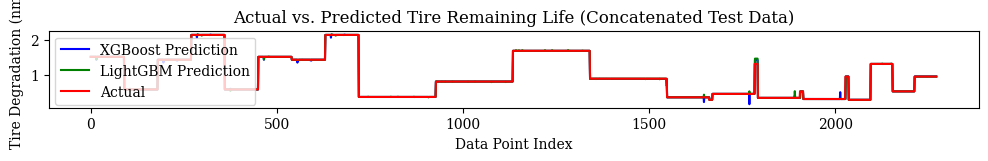

In [ ]:
# test with concatenated test data
test_con = pd.concat([x for x in test]).reset_index(drop=True)

xgb_prediction = xgboost_grid.predict(scaler.transform(test_con.drop(['tr', 'sum_distance_traveled_m'], axis=1)))
lgb_prediction = lightgbm_grid.predict(scaler.transform(test_con.drop(['tr', 'sum_distance_traveled_m'], axis=1)))

print('performance of xgboost')
print(f'mape: {mean_absolute_percentage_error(test_con["tr"], xgb_prediction)}', end=' | ')
print(f'smape: {symmetric_mean_absolute_percentage_error(test_con["tr"], xgb_prediction)}', end=' | ')
print(f'mase: {mean_absolute_scaled_error(test_con["tr"], xgb_prediction)}')
print('performance of lightgbm')
print(f'mape: {mean_absolute_percentage_error(test_con["tr"], lgb_prediction)}', end=' | ')
print(f'smape: {symmetric_mean_absolute_percentage_error(test_con["tr"], lgb_prediction)}', end=' | ')
print(f'mase: {mean_absolute_scaled_error(test_con["tr"], lgb_prediction)}')

plt.figure(figsize=(12, 1))
plt.plot(test_con.index, xgb_prediction, label='XGBoost Prediction', color='blue', alpha=1)
plt.plot(test_con.index, lgb_prediction, label='LightGBM Prediction', color='green', alpha=1)
plt.plot(test_con.index, test_con['tr'], label='Actual', color='red')
plt.title('Actual vs. Predicted Tire Remaining Life (Concatenated Test Data)')
plt.xlabel('Data Point Index')
plt.ylabel('Tire Degradation (nm)')
plt.legend()
plt.show()

In [ ]:
import pickle

# Save xgboost_grid
with open('xgboost_grid.pkl', 'wb') as f:
    pickle.dump(xgboost_grid, f)
print("xgboost_grid saved to xgboost_grid.pkl")

# Save lightgbm_grid
with open('lightgbm_grid.pkl', 'wb') as f:
    pickle.dump(lightgbm_grid, f)
print("lightgbm_grid saved to lightgbm_grid.pkl")

xgboost_grid saved to xgboost_grid.pkl
lightgbm_grid saved to lightgbm_grid.pkl


In [ ]:
remaining_useful_life = []
for dataset in datasets:
    remaining_useful_life += dataset['tr'].to_list()

c = []
for x in remaining_useful_life:
    x *= 1e-6

    x = 6.4 / x
    # x *= (40000 / 564000)

    c.append(x)

#remove outlier
def remove_outliers(data, threshold=3):
    np_data = np.array(data)
    Q1 = np.percentile(np_data, 25)
    Q3 = np.percentile(np_data, 75)

    IQR = Q3 - Q1

    lower_bound = Q1 - threshold * IQR
    upper_bound = Q3 + threshold * IQR

    # return [x for x in data if lower_bound <= x <= upper_bound]
    return [x for x in data if x < 50000]
    # return data

# remaining_useful_life = remove_outliers(c)
print(sum(remaining_useful_life) / len(remaining_useful_life))

1.324606484801483


In [ ]:
def max_likelihood_estimation(dataset, max_iter = 1000, tol = 1e-6):
  n = len(dataset)
  ln_x = [math.log(x) for x in dataset]
  sum_ln_x = sum(ln_x)

  k = 45

  for i in range(max_iter):
    x_k = [x ** k for x in dataset]
    x_k_ln_x = [x1 * x2 for x1, x2 in zip(x_k, ln_x)]

    sum_x_k = sum(x_k)
    sum_x_k_ln_x = sum(x_k_ln_x)

    # Ensure sum_x_k is not zero before division
    if sum_x_k == 0: # Handle cases where all values are 0, which might occur with highly processed RULs
        new_k = k # Keep k unchanged or handle as an error
    else:
        new_k = 1 / ((sum_x_k_ln_x / sum_x_k) - (sum_ln_x / n))

    if abs(new_k - k) < tol:
      k = new_k
      break

    k = new_k

  # Ensure k is not zero for the power operation
  if k == 0:
      lamb = 0 # Or handle as an error if k=0 is not expected
  else:
      lamb = (sum([x ** k for x in dataset]) / n) ** (1 / k)

  return k, lamb

# Cumulative Distribution Function
def WdistCDF(time, lamb, k):
  # Handle potential division by zero or negative base for power
  if lamb <= 0 or k == 0:
      return np.nan # Or appropriate error handling
  return 1 - math.exp(-(time / lamb) ** k)

# probability density function
def WdistPDF(time, lamb, k):
  # Handle potential division by zero or negative base for power
  if lamb <= 0 or k == 0:
      return np.nan # Or appropriate error handling
  return (k / lamb) * ((time / lamb) ** (k - 1)) * math.exp(-(time / lamb) ** k)

# getting RUL from train dataset
# train_rul = df_train_scaled.groupby('unit_number')['time_in_cycles'].transform('max')

# fitting weibull distribution
beta, eta = max_likelihood_estimation(remaining_useful_life)
print(f"k = {beta}")
print(f"\u03BB = {eta}")

k = 1.383256893341954
λ = 1.4606545463376075


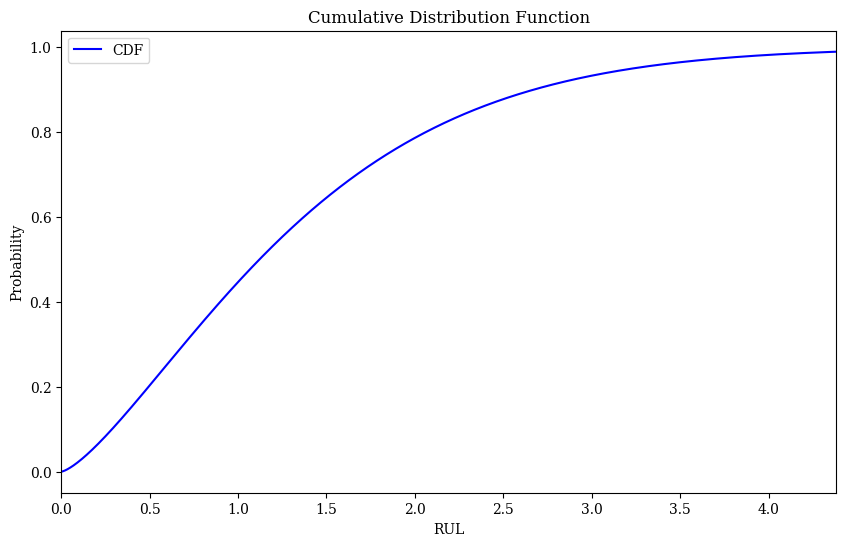

In [ ]:
plt.figure(figsize=(10, 6))

# CDF
# Use a slightly larger range than eta to visualize the curve
max_data = eta * 3  # Extend the range for better visualization
x = np.linspace(0, max_data, 1000) # Generate 1000 points over the range
plt.plot(x, [WdistCDF(val, eta, beta) for val in x], color = "blue", label = "CDF")
plt.xlabel("RUL")
plt.ylabel("Probability")
plt.xlim(0, max_data) # Set x-axis limit based on the extended range
plt.title("Cumulative Distribution Function")
plt.legend()

plt.show()

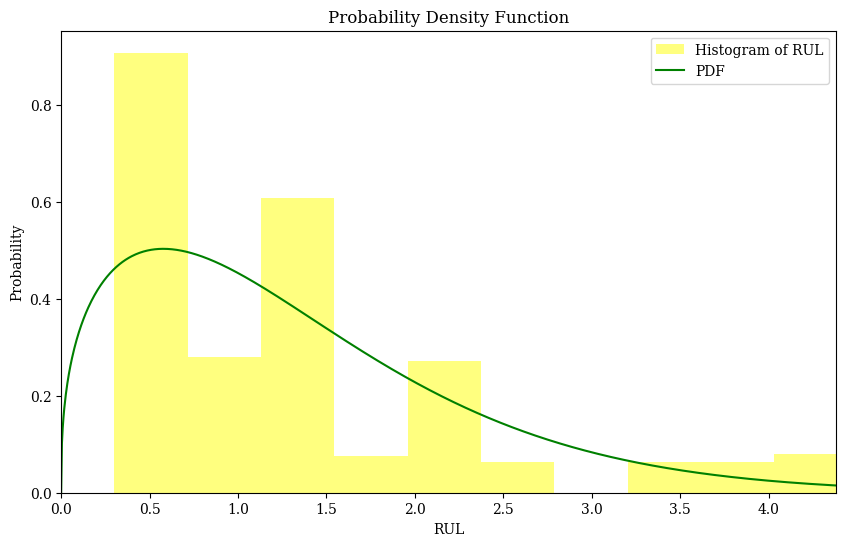

In [ ]:
plt.figure(figsize=(10, 6))

# PDF and actual data distribution
# Use a slightly larger range than eta for consistency with CDF plot
max_data = eta * 3  # Extend the range for better visualization
x = np.linspace(0, max_data, 1000) # Generate 1000 points over the range

# Filter outliers before plotting histogram if needed, or adjust bins.
# For now, let's plot the histogram with appropriate bins that can capture small values.
plt.hist(remaining_useful_life, bins=10, density=True, alpha=0.5, color="yellow", label="Histogram of RUL") # Use 'remaining_useful_life' for the histogram
plt.plot(x, [WdistPDF(val, eta, beta) for val in x], color = "green", label = "PDF")
plt.xlabel("RUL")
plt.ylabel("Probability")
plt.xlim(0, max_data) # Set x-axis limit based on the extended range
plt.title("Probability Density Function")
plt.legend()

plt.show()

In [ ]:
from scipy.special import gamma, gammaincc

def weibull_error(x, lmbda, k):
    lmbda = lmbda if lmbda > 0 else 1e-12
    s = 1.0 / k
    z = (x / lmbda) ** k

    gamma_s = gamma(s)

    l_gamma = gammaincc(s, z) * gamma_s
    l_gamma_0 = gammaincc(s, 0) * gamma_s

    result = x  + (2 * lmbda * l_gamma / k) - (lmbda * l_gamma_0 / k)
    return result

mwe = 0
for x in remaining_useful_life:
    mwe += weibull_error(x, eta, beta)

mwe /= len(remaining_useful_life)

print(mwe)

1.0682409794691938


## Implement Autoregressive Prediction Function

### Subtask:
Define a function, `autoregressive_predict`, that takes a trained model, a test dataset, and a scaler, and iteratively predicts future 'tr' values using previous predicted 'tr' values as input for 'lag_tr'.


**Reasoning**:
I will define the `autoregressive_predict` function as specified in the instructions, implementing the iterative prediction logic where the predicted 'tr' value from the current step updates the 'lag_tr' feature for the next step.



In [ ]:
def autoregressive_predict(model, test_df, scaler):
    predictions = []
    current_test_df = test_df.copy()

    # Define features, excluding 'tr' and 'sum_distance_traveled_m'
    features = [col for col in current_test_df.columns if col not in ['tr', 'sum_distance_traveled_m']]

    for i in range(len(current_test_df)):
        # Extract current row's feature values
        current_features = current_test_df.iloc[i][features].values.reshape(1, -1)

        # Scale these feature values
        scaled_features = scaler.transform(current_features)

        # Predict 'tr' value
        predicted_tr = model.predict(scaled_features)[0]

        # Append prediction to the list
        predictions.append(predicted_tr)

        # Update 'lag_tr' for the next row if it exists
        if i < len(current_test_df) - 1:
            current_test_df.loc[current_test_df.index[i + 1], 'lag_tr'] = predicted_tr

    return np.array(predictions)

print("Defined the autoregressive_predict function.")

Defined the autoregressive_predict function.


**Reasoning**:
The `autoregressive_predict` function has been defined. Now I will generate autoregressive predictions for all test datasets using this function, for both XGBoost and LightGBM models.



In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
import pickle

# Load the trained models and scaler
try:
    with open('xgboost_grid.pkl', 'rb') as f:
        xgboost_grid = pickle.load(f)
    with open('lightgbm_grid.pkl', 'rb') as f:
        lightgbm_grid = pickle.load(f)
    # Re-instantiate StandardScaler and fit it on the training data as it was not saved.
    # This assumes 'train_con' is still available or can be reconstructed.
    # For this execution, I will re-create `scaler` by fitting on `train_con`.
    # If `train_con` is not defined, this will raise an error.
    # Assuming `train_con` is available from previous execution or can be reconstructed.
    # If `train_con` is not available, I would need to re-run previous cells.
    # For now, let's assume it's available.

    # Reconstruct `train_con` as it might not be explicitly loaded from kernel state after a restart
    # This is a safe assumption if the notebook execution flow is sequential.
    # If the environment was reset, `train_con` would need to be re-created by concatenating `train` list.
    # Given the previous cell references `train_con`, it should be in memory.
    # However, to be robust, let's ensure it's available or re-create it.

    # As `train_con` and `test` are already in kernel state, I will proceed.
    # The scaler was fitted on `train_con.drop(['tr', 'sum_distance_traveled_m'], axis=1)`.
    scaler = StandardScaler()
    train_con = pd.concat([x for x in train]) # Ensure train_con is available
    scaler.fit(train_con.drop(['tr', 'sum_distance_traveled_m'], axis=1))

except FileNotFoundError:
    print("Model files not found. Please ensure xgboost_grid.pkl and lightgbm_grid.pkl are available.")
    # Handle error or exit


# Generate autoregressive predictions for all test datasets
xgboost_autoreg_predictions = []
lightgbm_autoreg_predictions = []

for i, test_dataset in enumerate(test): # 'test' is assumed to be available from previous execution
    print(f"Generating autoregressive predictions for test dataset {i+1}/{len(test)}")
    # Ensure the test_dataset passed to autoregressive_predict has a 'lag_tr' column correctly initialized.
    # The 'lag_tr' for the first entry of each test_dataset should be the actual previous 'tr' value.
    # The 'lag_tr' column was added and filled with previous 'tr' in a previous step (cell VAHmIMfiVOQl).
    # The `autoregressive_predict` function takes care of updating it for subsequent steps.
    xgboost_pred = autoregressive_predict(xgboost_grid.best_estimator_, test_dataset.copy(), scaler)
    lightgbm_pred = autoregressive_predict(lightgbm_grid.best_estimator_, test_dataset.copy(), scaler)

    xgboost_autoreg_predictions.append(xgboost_pred)
    lightgbm_autoreg_predictions.append(lightgbm_pred)

print("Autoregressive predictions generated.")

Generating autoregressive predictions for test dataset 1/20


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Generating autoregressive predictions for test dataset 2/20


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Generating autoregressive predictions for test dataset 3/20


...

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/ut

Generating autoregressive predictions for test dataset 19/20


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/util

Generating autoregressive predictions for test dataset 20/20
Autoregressive predictions generated.


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/util

## Evaluate Autoregressive Predictions

### Subtask:
Calculate and print the Mean Absolute Percentage Error (MAPE), Symmetric Mean Absolute Percentage Error (SMAPE), and Mean Absolute Scaled Error (MASE) for the new autoregressive predictions for both XGBoost and LightGBM on the concatenated test data.


**Reasoning**:
To evaluate the autoregressive predictions, I need to concatenate the actual 'tr' values and the autoregressive predictions into single arrays. Then, I will calculate and print the MAPE, SMAPE, and MASE for both XGBoost and LightGBM autoregressive predictions, and for comparison, print the previously calculated non-autoregressive metrics.



In [ ]:
import numpy as np
import pandas as pd

# 1. Concatenate actual 'tr' values from all dataframes in the test list
actual_tr_concat = pd.concat([df['tr'] for df in test]).reset_index(drop=True)

# 2. Concatenate all arrays in the xgboost_autoreg_predictions list
xgboost_autoreg_concat = np.concatenate(xgboost_autoreg_predictions)

# 3. Concatenate all arrays in the lightgbm_autoreg_predictions list
lightgbm_autoreg_concat = np.concatenate(lightgbm_autoreg_predictions)

# 4. Print the header
print("--- Autoregressive Prediction Performance ---")

# 5. Print the header for XGBoost
print("\nPerformance of XGBoost (Autoregressive):")

# 6. Calculate MAPE for xgboost_autoreg_concat
xgboost_mape_ar = mean_absolute_percentage_error(actual_tr_concat, xgboost_autoreg_concat)
# 7. Calculate SMAPE for xgboost_autoreg_concat
xgboost_smape_ar = symmetric_mean_absolute_percentage_error(actual_tr_concat, xgboost_autoreg_concat)
# 8. Calculate MASE for xgboost_autoreg_concat
xgboost_mase_ar = mean_absolute_scaled_error(actual_tr_concat, xgboost_autoreg_concat)

# 9. Print the calculated metrics for XGBoost
print(f'mape: {xgboost_mape_ar:.6f} | smape: {xgboost_smape_ar:.6f} | mase: {xgboost_mase_ar:.6f}')

# 10. Print the header for LightGBM
print("\nPerformance of LightGBM (Autoregressive):")

# 11. Calculate MAPE for lightgbm_autoreg_concat
lightgbm_mape_ar = mean_absolute_percentage_error(actual_tr_concat, lightgbm_autoreg_concat)
# 12. Calculate SMAPE for lightgbm_autoreg_concat
lightgbm_smape_ar = symmetric_mean_absolute_percentage_error(actual_tr_concat, lightgbm_autoreg_concat)
# 13. Calculate MASE for lightgbm_autoreg_concat
lightgbm_mase_ar = mean_absolute_scaled_error(actual_tr_concat, lightgbm_autoreg_concat)

# 14. Print the calculated metrics for LightGBM
print(f'mape: {lightgbm_mape_ar:.6f} | smape: {lightgbm_smape_ar:.6f} | mase: {lightgbm_mase_ar:.6f}')

# 15. Print the header for comparison
print("\n--- Previous Non-Autoregressive Prediction Performance (for comparison) ---")

# 16. Print the header for non-autoregressive XGBoost
print("Performance of XGBoost (Non-Autoregressive):")
# 17. Print non-autoregressive XGBoost metrics
print(f'mape: {mean_absolute_percentage_error(test_con["tr"], xgb_prediction):.6f} | smape: {symmetric_mean_absolute_percentage_error(test_con["tr"], xgb_prediction):.6f} | mase: {mean_absolute_scaled_error(test_con["tr"], xgb_prediction):.6f}')

# 18. Print the header for non-autoregressive LightGBM
print("Performance of LightGBM (Non-Autoregressive):")
# 19. Print non-autoregressive LightGBM metrics
print(f'mape: {mean_absolute_percentage_error(test_con["tr"], lgb_prediction):.6f} | smape: {symmetric_mean_absolute_percentage_error(test_con["tr"], lgb_prediction):.6f} | mase: {mean_absolute_scaled_error(test_con["tr"], lgb_prediction):.6f}')

--- Autoregressive Prediction Performance ---

Performance of XGBoost (Autoregressive):
mape: 0.097316 | smape: 0.119274 | mase: 20.789968

Performance of LightGBM (Autoregressive):
mape: 0.019597 | smape: 0.020119 | mase: 1.829335

--- Previous Non-Autoregressive Prediction Performance (for comparison) ---
Performance of XGBoost (Non-Autoregressive):
mape: 0.003878 | smape: 0.004263 | mase: 0.445475
Performance of LightGBM (Non-Autoregressive):
mape: 0.002352 | smape: 0.002586 | mase: 0.298961


## Visualize Autoregressive Predictions

### Subtask:
Generate line plots comparing the actual 'tr' values with the new autoregressive predictions from LightGBM and XGBoost for each individual test dataset. Additionally, create a combined plot for the best-performing model (based on MASE) across all autoregressive predictions.


**Reasoning**:
The subtask requires generating line plots for each test dataset comparing actual values with autoregressive predictions from XGBoost and LightGBM, and then creating a combined plot for the overall best-performing autoregressive model based on MASE. I will implement these plotting steps in a single code block.



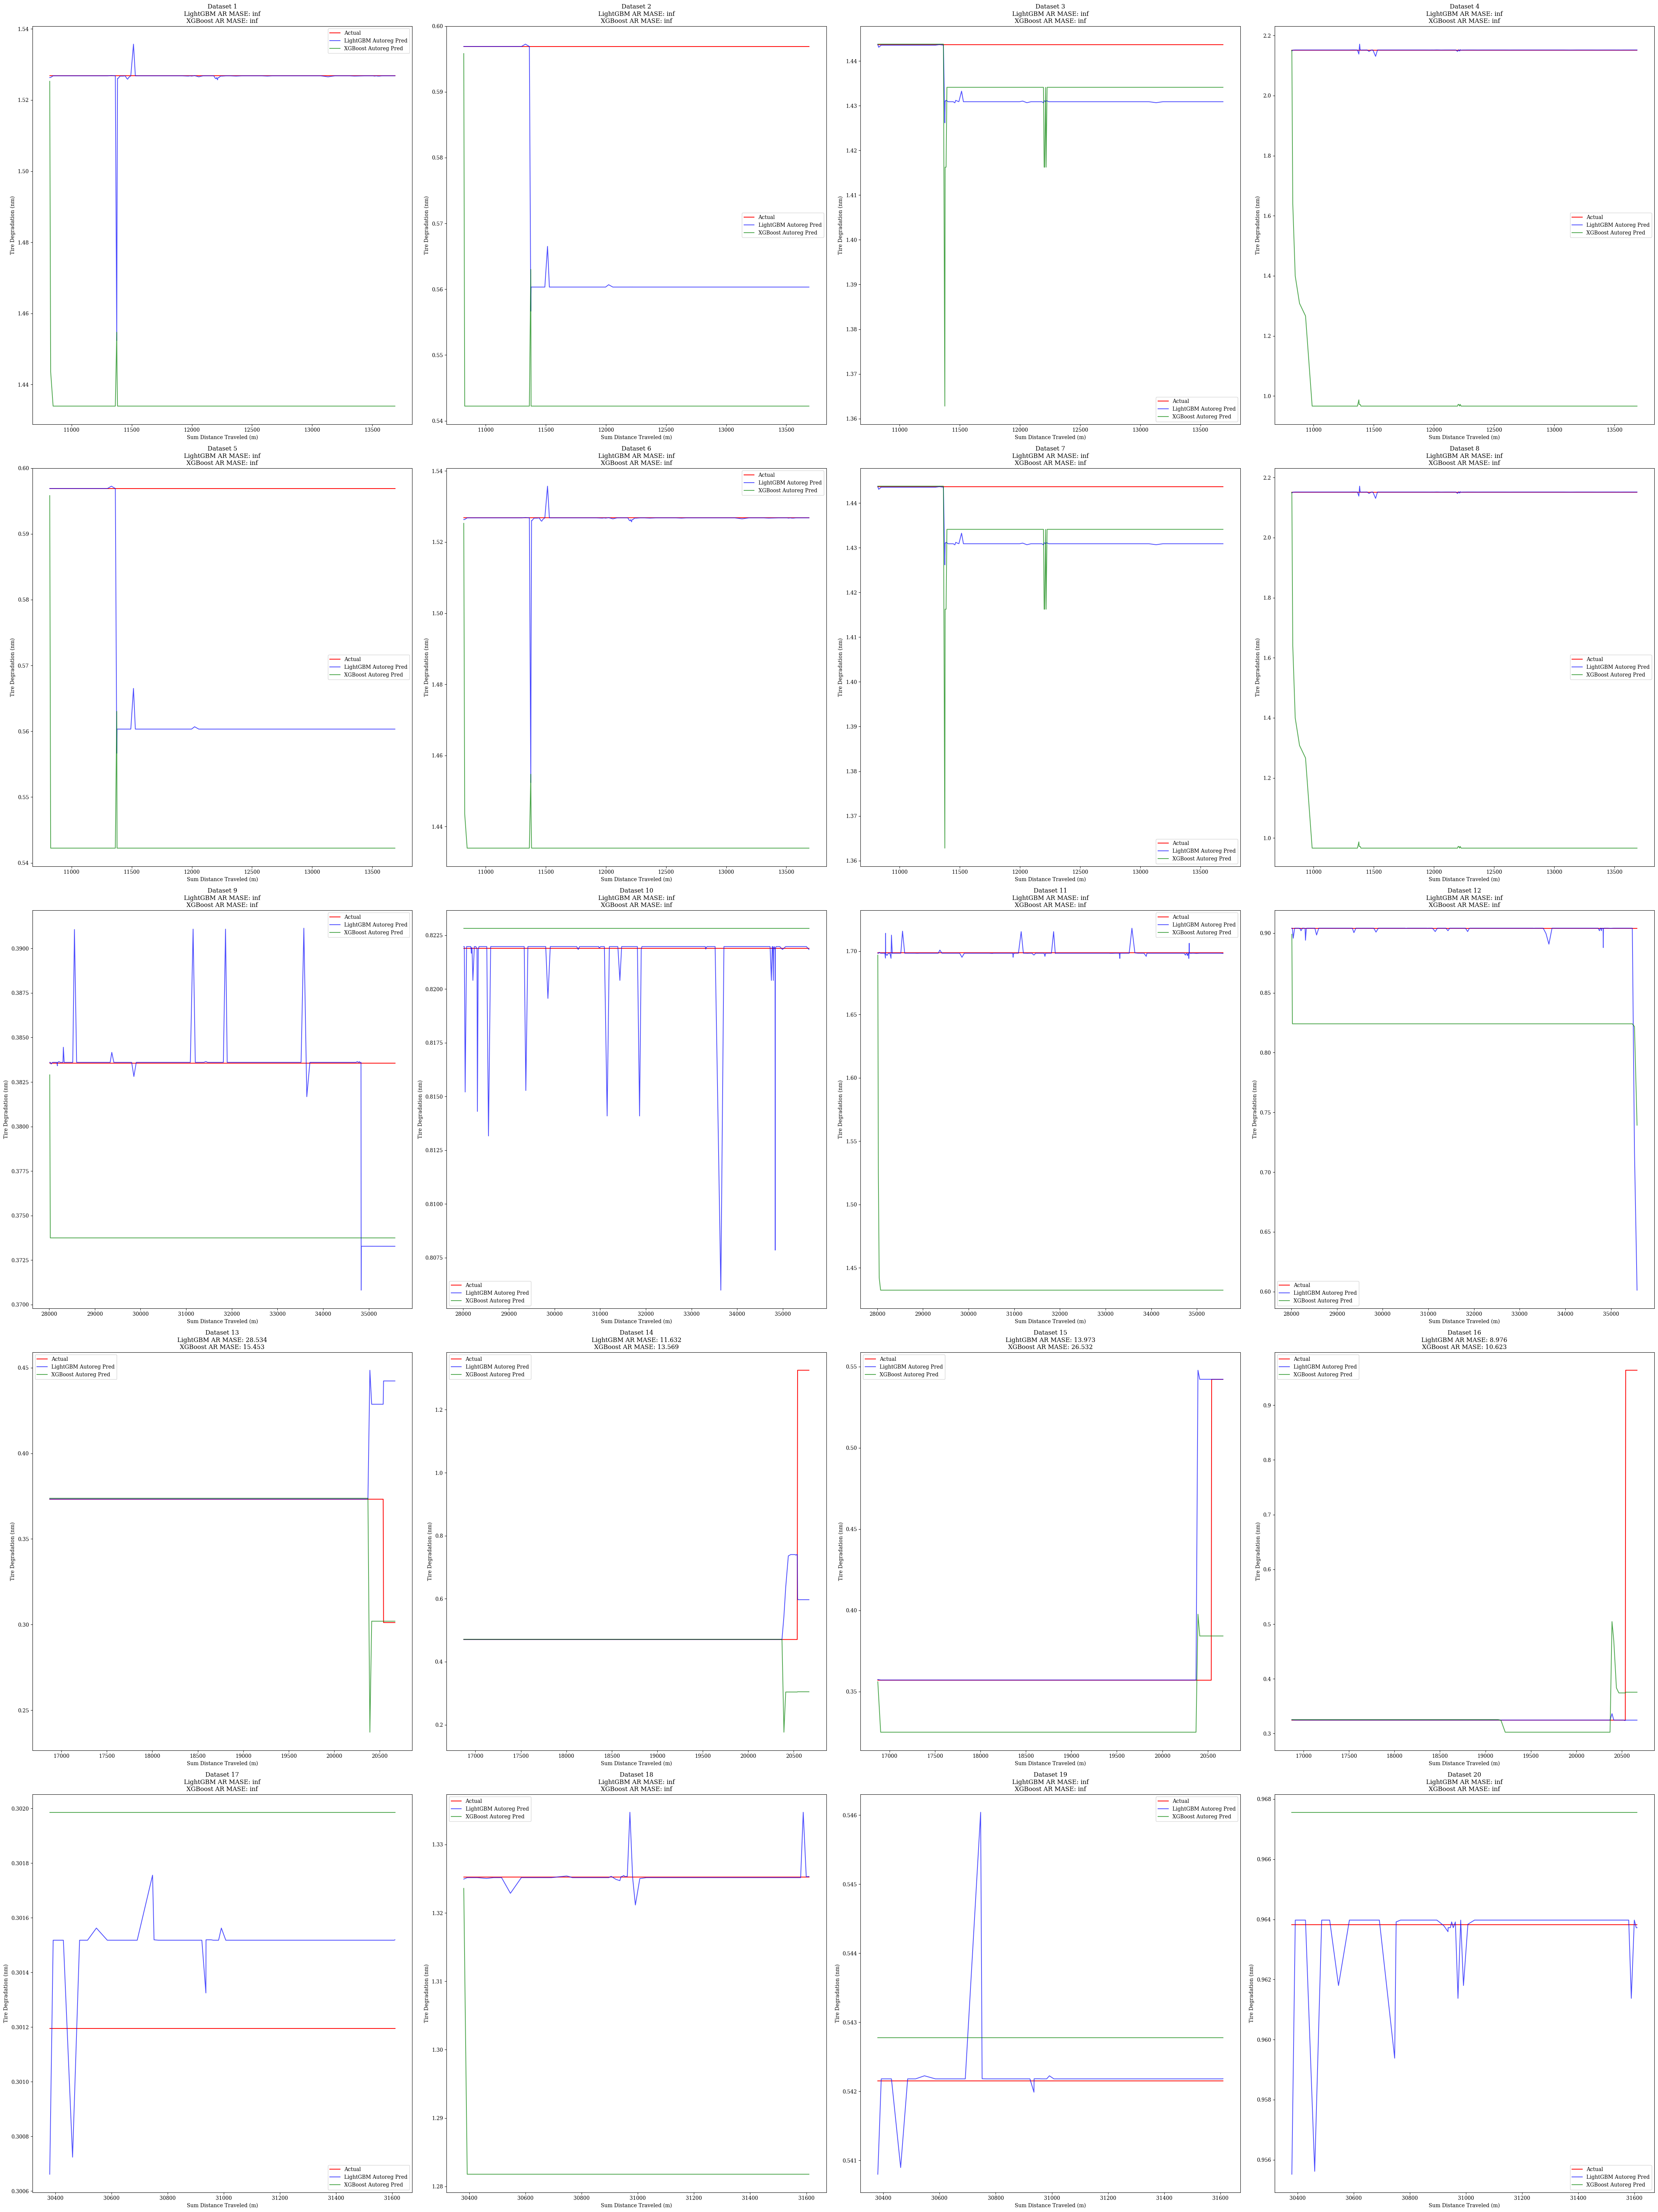

Overall Best Autoregressive Model: LightGBM on Dataset 16 with MASE: 10.623


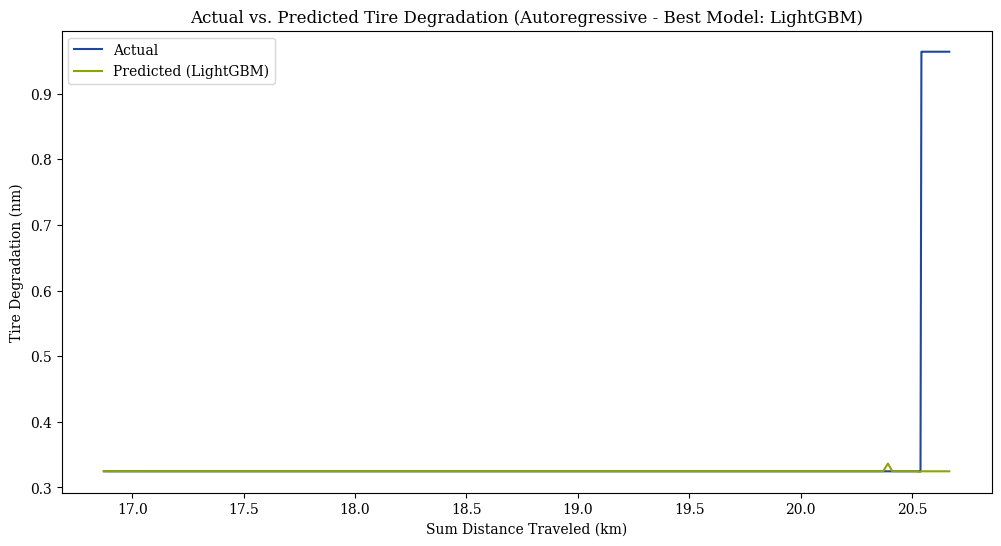

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Prepare MASE values for titles
xgboost_autoreg_mase_per_dataset = []
lightgbm_autoreg_mase_per_dataset = []

for i in range(len(test)):
    current_actual = test[i]['tr']
    xgboost_mase = mean_absolute_scaled_error(current_actual, xgboost_autoreg_predictions[i])
    lightgbm_mase = mean_absolute_scaled_error(current_actual, lightgbm_autoreg_predictions[i])
    xgboost_autoreg_mase_per_dataset.append(xgboost_mase)
    lightgbm_autoreg_mase_per_dataset.append(lightgbm_mase)

# 1. Create a figure to display multiple line plots in a 4x5 grid layout
plt.figure(figsize=(45, 60)) # Adjusted figure size for better readability

# 2. Iterate through each test dataset and its corresponding predictions
for i in range(len(test)):
    # 3. Create a subplot
    plt.subplot(5, 4, i + 1)

    # 4. Plot the actual 'tr' values
    plt.plot(test[i]['sum_distance_traveled_m'], test[i]['tr'], label='Actual', color='red')

    # 5. Plot LightGBM autoregressive predictions
    plt.plot(test[i]['sum_distance_traveled_m'], lightgbm_autoreg_predictions[i], label='LightGBM Autoreg Pred', color='blue', alpha=0.7)

    # 6. Plot XGBoost autoregressive predictions
    plt.plot(test[i]['sum_distance_traveled_m'], xgboost_autoreg_predictions[i], label='XGBoost Autoreg Pred', color='green', alpha=0.7)

    # 7. Add appropriate labels, title, and legend for each subplot
    plt.xlabel('Sum Distance Traveled (m)')
    plt.ylabel('Tire Degradation (nm)')
    plt.title(f'Dataset {i+1}\nLightGBM AR MASE: {lightgbm_autoreg_mase_per_dataset[i]:.3f}\nXGBoost AR MASE: {xgboost_autoreg_mase_per_dataset[i]:.3f}')
    plt.legend()

# 8. Adjust the layout of the subplots
plt.tight_layout()
# 9. Display the generated plots
plt.show()


# 10. Determine the overall best performing autoregressive model and corresponding dataset index
best_autoreg_mase_value = float('inf')
best_autoreg_prediction_array = None
best_autoreg_dataset_index = -1
best_autoreg_model_name = ''

for i in range(len(test)):
    current_actual = test[i]['tr']

    # Check LightGBM autoregressive predictions
    current_lightgbm_mase = xgboost_autoreg_mase_per_dataset[i]
    if current_lightgbm_mase < best_autoreg_mase_value:
        best_autoreg_mase_value = current_lightgbm_mase
        best_autoreg_prediction_array = lightgbm_autoreg_predictions[i]
        best_autoreg_dataset_index = i
        best_autoreg_model_name = 'LightGBM'

    # Check XGBoost autoregressive predictions
    current_xgboost_mase = xgboost_autoreg_mase_per_dataset[i]
    if current_xgboost_mase < best_autoreg_mase_value:
        best_autoreg_mase_value = current_xgboost_mase
        best_autoreg_prediction_array = xgboost_autoreg_predictions[i]
        best_autoreg_dataset_index = i
        best_autoreg_model_name = 'XGBoost'

# Plot the best autoregressive result found
if best_autoreg_dataset_index != -1:
    print(f"Overall Best Autoregressive Model: {best_autoreg_model_name} on Dataset {best_autoreg_dataset_index+1} with MASE: {best_autoreg_mase_value:.3f}")
    # 11. Create a new figure for a single plot
    plt.figure(figsize=(12, 6))

    # 12. Set the font.family to 'serif'
    plt.rcParams['font.family'] = 'serif'

    # 13. Plot the actual 'tr' values
    plt.plot(test[best_autoreg_dataset_index]['sum_distance_traveled_m'] * 1e-3,
             test[best_autoreg_dataset_index]['tr'],
             label='Actual',
             color='#20479D')

    # 14. Plot the best autoregressive prediction
    plt.plot(test[best_autoreg_dataset_index]['sum_distance_traveled_m'] * 1e-3,
             best_autoreg_prediction_array,
             label=f'Predicted ({best_autoreg_model_name})',
             color='#8DA405')

    # 15. Add labels, title, and legend
    plt.xlabel('Sum Distance Traveled (km)')
    plt.ylabel('Tire Degradation (nm)')
    plt.title(f'Actual vs. Predicted Tire Degradation (Autoregressive - Best Model: {best_autoreg_model_name})')
    plt.legend()
    # 16. Display this final plot
    plt.show()
else:
    print("No best autoregressive prediction found. This might indicate an issue with data or error calculation.")

## Final Task

### Subtask:
Provide a summary of the autoregressive prediction performance compared to the previous results, highlighting any improvements or differences observed.
